## Combine Dataset, copy zoom out to zoom in

In [1]:
import os
import shutil

def copy_files(src_dir, dest_dir):
    """
    Recursively copy files from the source directory to the destination directory,
    maintaining the directory structure.
    
    Args:
    - src_dir: The source directory to copy from
    - dest_dir: The destination directory to copy to
    """
    # Walk through the source directory
    for root, dirs, files in os.walk(src_dir):
        # Calculate relative path from the source directory
        rel_path = os.path.relpath(root, src_dir)
        # Define the corresponding destination path
        dest_path = os.path.join(dest_dir, rel_path)
        
        # Create the directories in the destination if they don't exist
        os.makedirs(dest_path, exist_ok=True)
        
        # Copy each file to the destination
        for file in files:
            src_file = os.path.join(root, file)
            dest_file = os.path.join(dest_path, file)
            shutil.copy2(src_file, dest_file)  # copy2 to preserve file metadata
            print(f"Copied: {src_file} -> {dest_file}")

def main():
    # Define source and destination directories
    src_train_dir = r"F:\SNAPFOLIA\TRAIN_ZOOM_OUT_CLS"
    src_test_dir = r"F:\SNAPFOLIA\TEST_ZOOM_OUT_CLS"
    dest_train_dir = r"F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train"
    dest_val_dir = r"F:\SNAPFOLIA\CLS_DS_59 - SPLIT\test"
    
    # Copy from dsout/train to dstest/train
    print("Copying files from dsout/train to dstest/train...")
    copy_files(src_train_dir, dest_train_dir)
    
    # Copy from dsout/val to dstest/val
    print("Copying files from dsout/val to dstest/val...")
    copy_files(src_test_dir, dest_val_dir)
    
    print("\nFiles copied successfully!")

if __name__ == "__main__":
    main()


Copying files from dsout/train to dstest/train...
Copied: F:\SNAPFOLIA\TRAIN_ZOOM_OUT_CLS\Acacia\env_Acacia-B-9-_jpg.rf.07e6b7ace3d67f9749d2b57c721c2777(z0.84).jpg -> F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Acacia\env_Acacia-B-9-_jpg.rf.07e6b7ace3d67f9749d2b57c721c2777(z0.84).jpg
Copied: F:\SNAPFOLIA\TRAIN_ZOOM_OUT_CLS\Acacia\env_Acacia-C-5-_jpg.rf.0d9ae3c4b075716e933be64fe3400e29(z0.64).jpg -> F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Acacia\env_Acacia-C-5-_jpg.rf.0d9ae3c4b075716e933be64fe3400e29(z0.64).jpg
Copied: F:\SNAPFOLIA\TRAIN_ZOOM_OUT_CLS\Acacia\env_Acacia-D-1-_jpg.rf.a86050297b140f7baef8b48b2a4d81da(z0.88).jpg -> F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Acacia\env_Acacia-D-1-_jpg.rf.a86050297b140f7baef8b48b2a4d81da(z0.88).jpg
Copied: F:\SNAPFOLIA\TRAIN_ZOOM_OUT_CLS\Acacia\env_Acacia-D-28-_jpg.rf.47832b52f99df5122d7f8b2ad7037750(z0.68).jpg -> F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Acacia\env_Acacia-D-28-_jpg.rf.47832b52f99df5122d7f8b2ad7037750(z0.68).jpg
Copied: F:\SNAPFOLIA\TRAIN_ZOOM_OUT_

### Visualize 

Counting images in dataset...
Plotting class distribution...


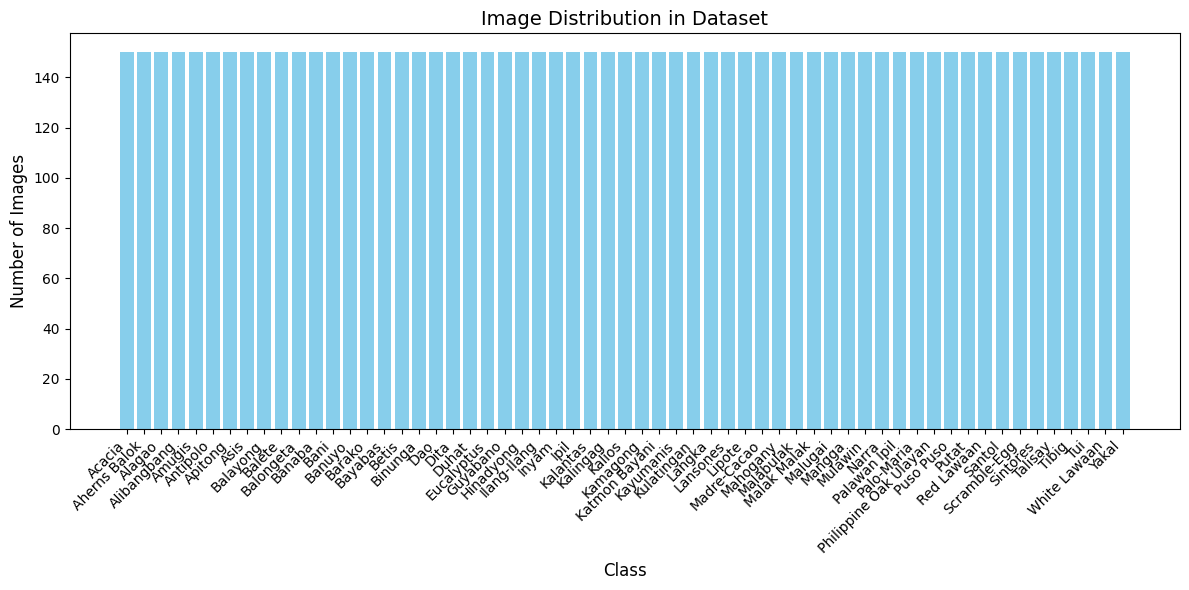

In [ ]:
import os
import matplotlib.pyplot as plt

def count_images_in_classes(dataset_path):
    """Counts images in each class folder within the given dataset path."""
    class_counts = {
        class_name: len([
            f for f in os.listdir(os.path.join(dataset_path, class_name)) 
            if os.path.isfile(os.path.join(dataset_path, class_name, f))
        ])
        for class_name in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, class_name))
    }
    return dict(sorted(class_counts.items()))

def plot_class_distribution(class_counts, title="Dataset Distribution"):
    """Plots the distribution of images across classes."""
    plt.figure(figsize=(12, 6))
    plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.title(title, fontsize=14)
    
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    dataset_path = r"F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train"

    print("Counting images in dataset...")
    class_counts = count_images_in_classes(dataset_path)

    if class_counts:
        print("Plotting class distribution...")
        plot_class_distribution(class_counts, title="Image Distribution in Dataset")
    else:
        print("No valid class folders found in the dataset path.")


## Generate Rotations for Train and Test

In [5]:
import os
import cv2
import numpy as np

def augment_class(original_class_path, target_count, angles=[90, 180, 270]):
    """Augment images for a specific class until reaching the target count."""
    image_files = [f for f in os.listdir(original_class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    current_count = len(image_files)

    if current_count >= target_count:
        return

    augmentation_needed = target_count - current_count
    aug_counter, angle_idx = 0, 0

    while aug_counter < augmentation_needed:
        for img_file in image_files:
            if aug_counter >= augmentation_needed:
                break

            img_path = os.path.join(original_class_path, img_file)

            img = cv2.imread(img_path)
            if img is None:
                continue

            height, width = img.shape[:2]

            angle = angles[angle_idx % len(angles)]
            rotation_matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
            rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height))

            aug_suffix = f'_aug_{angle}_{aug_counter}'
            new_img_file = f"{img_file.rsplit('.', 1)[0]}{aug_suffix}.{img_file.rsplit('.', 1)[1]}"

            cv2.imwrite(os.path.join(original_class_path, new_img_file), rotated_img)

            aug_counter += 1
            angle_idx += 1

def balance_dataset(base_dir, target_count=None):
    """Balance the dataset by augmenting classes with fewer images."""
    class_counts = {}
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
            class_counts[class_name] = len(image_files)
    
    target_count = target_count or max(class_counts.values())
    print(f"Target count per class: {target_count}")

    for class_name, count in class_counts.items():
        print(f"\nProcessing class '{class_name}' ({count} images)")
        class_path = os.path.join(base_dir, class_name)
        augment_class(class_path, target_count)
        
        new_count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        print(f"Augmented '{class_name}' to {new_count} images")

    print("\nDataset augmentation complete.")

if __name__ == "__main__":
    base_dir = r"F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train"  # ADJUST FOR YOUR DATASET
    balance_dataset(base_dir, target_count=1050)

Target count per class: 1050

Processing class 'Acacia' (525 images)
Augmented 'Acacia' to 1050 images

Processing class 'Aherns Balok' (484 images)
Augmented 'Aherns Balok' to 1091 images

Processing class 'Alagao' (525 images)
Augmented 'Alagao' to 1050 images

Processing class 'Alibangbang' (525 images)
Augmented 'Alibangbang' to 1050 images

Processing class 'Amugis' (525 images)
Augmented 'Amugis' to 1050 images

Processing class 'Antipolo' (516 images)
Augmented 'Antipolo' to 1059 images

Processing class 'Apitong' (525 images)
Augmented 'Apitong' to 1050 images

Processing class 'Asis' (525 images)
Augmented 'Asis' to 1050 images

Processing class 'Balayong' (525 images)
Augmented 'Balayong' to 1050 images

Processing class 'Balete' (525 images)
Augmented 'Balete' to 1050 images

Processing class 'Balongeta' (525 images)
Augmented 'Balongeta' to 1050 images

Processing class 'Banaba' (525 images)
Augmented 'Banaba' to 1050 images

Processing class 'Bani' (525 images)
Augmented '

In [8]:
from ultralytics import YOLO
from datetime import datetime

model = YOLO('yolov8n-cls.pt') 

start_time = datetime.now()
print(f"Training started at: {start_time}")
print("--------------------------------------")

train_results = model.train(data="F:\SNAPFOLIA\CLS_DS_59 - SPLIT", epochs=10, imgsz=640, batch=4, device=0)

end_time = datetime.now()
print("--------------------------------------")
print(f"Training ended at: {end_time}")

duration = end_time - start_time
print("--------------------------------------")
print(f"Training duration: {duration}")

Training started at: 2025-04-13 08:08:27.469402
--------------------------------------
New https://pypi.org/project/ultralytics/8.3.107 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.57  Python-3.9.12 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=F:\SNAPFOLIA\CLS_DS_59 - SPLIT, epochs=10, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize

train: Scanning F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train... 61950 images, 0 corrupt: 100%|██████████| 61950/61950 [28:19<00:00, 36.46it/s]  

train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (1).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (10).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (11).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (12).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (13).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (14).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (15).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G (16).jpg: corrupt JPEG restored and saved
train: WARNING  F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train\Antipolo\Antipolo 3G

train: New cache created: F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train.cache


val: Scanning F:\SNAPFOLIA\CLS_DS_59 - SPLIT\test... 17700 images, 0 corrupt: 100%|██████████| 17700/17700 [13:46<00:00, 21.41it/s] 

...

      10/10      0.47G    0.04664          2        640: 100%|██████████| 15488/15488 [1:07:48<00:00,  3.81it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 2213/2213 [21:36<00:00,  1.71it/s]

                   all      0.991          1



10 epochs completed in 15.417 hours.
Optimizer stripped from runs\classify\train\weights\last.pt, 3.1MB
Optimizer stripped from runs\classify\train\weights\best.pt, 3.1MB

Validating runs\classify\train\weights\best.pt...
Ultralytics YOLOv8.2.57  Python-3.9.12 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,510,459 parameters, 0 gradients, 3.3 GFLOPs
WARNING  Dataset 'split=val' not found, using 'split=test' instead.
train: F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train... found 61950 images in 59 classes  
val: None...
test: F:\SNAPFOLIA\CLS_DS_59 - SPLIT\test... found 17700 images in 59 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 2213/2213 [09:48<00:00,  3.76it/s]


                   all      0.991      0.999
Speed: 1.2ms preprocess, 2.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train
Results saved to runs\classify\train
--------------------------------------
Training ended at: 2025-04-14 00:30:19.989753
--------------------------------------
Training duration: 16:21:52.520351
